In [4]:
# Importações básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Bibliotecas especializadas
# import missingno as msno
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
# import category_encoders as ce
import math
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

print(" Bibliotecas importadas!")

 Bibliotecas importadas!


Carregamento e Exploração de Dados

In [5]:
from pathlib import Path
import pandas as pd

path = Path('../../data/Airbnb Prices in European Cities/raw')

file_name = "london_weekdays.csv"
file_path = path / file_name

df = pd.read_csv(file_path)

print("Lido")


Lido


In [6]:
cols_lfs = [
    'version https://git-lfs.github.com/spec/v1',
    'oid sha256',
    'size'
]

df = df.drop(columns=[c for c in cols_lfs if c in df.columns])


Análise Exploratória Estrutural

In [7]:
# 1. Informações básicas do dataset
print("\n1️⃣ INFORMAÇÕES GERAIS:")
print(f"Shape: {df.shape}")
print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


1️⃣ INFORMAÇÕES GERAIS:
Shape: (4614, 20)
Memória: 0.89 MB


In [8]:
# 2. Tipos de dados
print("\n2️⃣ TIPOS DE DADOS:")
print(df.dtypes)


2️⃣ TIPOS DE DADOS:
Unnamed: 0                      int64
realSum                       float64
room_type                      object
room_shared                      bool
room_private                     bool
person_capacity               float64
host_is_superhost                bool
multi                           int64
biz                             int64
cleanliness_rating            float64
guest_satisfaction_overall    float64
bedrooms                        int64
dist                          float64
metro_dist                    float64
attr_index                    float64
attr_index_norm               float64
rest_index                    float64
rest_index_norm               float64
lng                           float64
lat                           float64
dtype: object


In [9]:
# 3. Primeiras linhas
print("\n3️⃣ PRIMEIRAS 5 LINHAS:")
display(df.head())


3️⃣ PRIMEIRAS 5 LINHAS:


,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
0,0,570.098074,Entire home/apt,False,False,2.0,False,0,0,10.0,98.0,1,5.301018,1.588990,209.632578,14.571793,467.597522,8.372724,-0.16032,51.46531
1,1,297.984430,Private room,False,True,2.0,True,1,0,10.0,99.0,1,2.198946,0.379262,553.891744,38.501630,961.472137,17.215961,-0.09683,51.50343
2,2,336.790611,Private room,False,True,2.0,False,1,0,10.0,96.0,1,2.322958,0.453178,428.287849,29.770764,959.042839,17.172462,-0.10554,51.52407
3,3,226.722171,Private room,False,True,2.0,True,1,0,10.0,99.0,1,5.707825,1.723977,195.694744,13.602959,452.232472,8.097600,-0.16575,51.46292
4,4,256.355982,Private room,False,True,3.0,False,0,0,9.0,98.0,1,3.257945,0.825417,329.477068,22.902317,735.327280,13.166649,-0.12055,51.53728


In [10]:
# 4. Informações detalhadas
print("\n4️⃣ INFO DETALHADA:")
df.info()


4️⃣ INFO DETALHADA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4614 entries, 0 to 4613
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  4614 non-null   int64  
 1   realSum                     4614 non-null   float64
 2   room_type                   4614 non-null   object 
 3   room_shared                 4614 non-null   bool   
 4   room_private                4614 non-null   bool   
 5   person_capacity             4614 non-null   float64
 6   host_is_superhost           4614 non-null   bool   
 7   multi                       4614 non-null   int64  
 8   biz                         4614 non-null   int64  
 9   cleanliness_rating          4614 non-null   float64
 10  guest_satisfaction_overall  4614 non-null   float64
 11  bedrooms                    4614 non-null   int64  
 12  dist                        4614 non-null   float64
 13  metro_dist  

In [11]:
# 5. Estatísticas descritivas
print("\n5️⃣ ESTATÍSTICAS DESCRITIVAS:")
display(df.describe())


5️⃣ ESTATÍSTICAS DESCRITIVAS:


,Unnamed: 0,realSum,person_capacity,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
count,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000
mean,2306.500000,360.230348,2.832466,0.269397,0.422844,9.153013,90.324447,1.123754,5.325023,0.992739,296.466825,20.607738,629.790258,11.276920,-0.114886,51.503262
std,1332.091401,507.782888,1.240572,0.443695,0.494065,1.183012,11.755838,0.581591,2.720524,1.262465,172.440566,11.986535,389.953206,6.982438,0.068183,0.031465
min,0.000000,64.676968,2.000000,0.000000,0.000000,2.000000,20.000000,0.000000,0.040553,0.013904,68.740487,4.778228,140.521726,2.516159,-0.251700,51.416510
25%,1153.250000,167.454550,2.000000,0.000000,0.000000,9.000000,86.000000,1.000000,3.553956,0.317995,178.041401,12.375855,386.186620,6.914994,-0.171242,51.486300
50%,2306.500000,256.355982,2.000000,0.000000,0.000000,9.000000,93.000000,1.000000,4.899843,0.523462,251.181941,17.459935,530.331957,9.496036,-0.118225,51.509800
75%,3459.750000,435.452386,4.000000,1.000000,1.000000,10.000000,99.000000,1.000000,6.835232,1.047957,361.797354,25.148936,775.523995,13.886404,-0.067260,51.524698
max,4613.000000,15499.894165,6.000000,1.000000,1.000000,10.000000,100.000000,8.000000,17.321206,9.286229,1438.618956,100.000000,5584.771840,100.000000,0.120180,51.575820


In [12]:
# 6. Análise de valores únicos
print("\n6️⃣ VALORES ÚNICOS POR COLUNA:")
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count}")


6️⃣ VALORES ÚNICOS POR COLUNA:
Unnamed: 0: 4614
realSum: 1752
room_type: 3
room_shared: 2
room_private: 2
person_capacity: 5
host_is_superhost: 2
multi: 2
biz: 2
cleanliness_rating: 9
guest_satisfaction_overall: 47
bedrooms: 7
dist: 4614
metro_dist: 4614
attr_index: 4614
attr_index_norm: 4614
rest_index: 4614
rest_index_norm: 4614
lng: 4006
lat: 3544


Análise de Missing Values

In [13]:
# 1. Contagem de missing values
print("\n1️⃣ MISSING VALUES POR COLUNA:")
missing_data = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)
print(missing_data)


1️⃣ MISSING VALUES POR COLUNA:
Empty DataFrame
Columns: [Coluna, Missing_Count, Missing_Percent]
Index: []


Análise Exploratória Univariada

In [14]:
# Separar variáveis por tipo
numeric_vars = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()

In [38]:
print(f"Variáveis numéricas: {numeric_vars}")
print(f"Variáveis categóricas: {categorical_vars}")

Variáveis numéricas: ['Unnamed: 0', 'realSum', 'person_capacity', 'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'attr_index', 'attr_index_norm', 'rest_index', 'rest_index_norm', 'lng', 'lat']
Variáveis categóricas: ['room_type']


In [16]:
# 1. ANÁLISE DE VARIÁVEIS NUMÉRICAS
print("\n1️⃣ ANÁLISE DE VARIÁVEIS NUMÉRICAS:")


1️⃣ ANÁLISE DE VARIÁVEIS NUMÉRICAS:


In [17]:
# Estatísticas descritivas detalhadas
for var in numeric_vars:
    if var in df.columns:
        print(f"\n📊 {var.upper()}:")
        data = df[var].dropna()

        # Estatísticas básicas
        print(f"  Mean: {data.mean():.2f}")
        print(f"  Median: {data.median():.2f}")
        print(f"  Std: {data.std():.2f}")
        print(f"  Skewness: {stats.skew(data):.2f}")
        print(f"  Kurtosis: {stats.kurtosis(data):.2f}")

        # Outliers (IQR method)
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")


📊 UNNAMED: 0:
  Mean: 2306.50
  Median: 2306.50
  Std: 1332.09
  Skewness: 0.00
  Kurtosis: -1.20
  Outliers: 0 (0.0%)

📊 REALSUM:
  Mean: 360.23
  Median: 256.36
  Std: 507.78
  Skewness: 16.95
  Kurtosis: 411.78
  Outliers: 247 (5.4%)

📊 PERSON_CAPACITY:
  Mean: 2.83
  Median: 2.00
  Std: 1.24
  Skewness: 1.29
  Kurtosis: 0.48
  Outliers: 0 (0.0%)

📊 MULTI:
  Mean: 0.27
  Median: 0.00
  Std: 0.44
  Skewness: 1.04
  Kurtosis: -0.92
  Outliers: 0 (0.0%)

📊 BIZ:
  Mean: 0.42
  Median: 0.00
  Std: 0.49
  Skewness: 0.31
  Kurtosis: -1.90
  Outliers: 0 (0.0%)

📊 CLEANLINESS_RATING:
  Mean: 9.15
  Median: 9.00
  Std: 1.18
  Skewness: -2.45
  Kurtosis: 9.18
  Outliers: 309 (6.7%)

📊 GUEST_SATISFACTION_OVERALL:
  Mean: 90.32
  Median: 93.00
  Std: 11.76
  Skewness: -2.55
  Kurtosis: 9.88
  Outliers: 176 (3.8%)

📊 BEDROOMS:
  Mean: 1.12
  Median: 1.00
  Std: 0.58
  Skewness: 1.50
  Kurtosis: 7.86
  Outliers: 1136 (24.6%)

📊 DIST:
  Mean: 5.33
  Median: 4.90
  Std: 2.72
  Skewness: 0.98
  Kurt

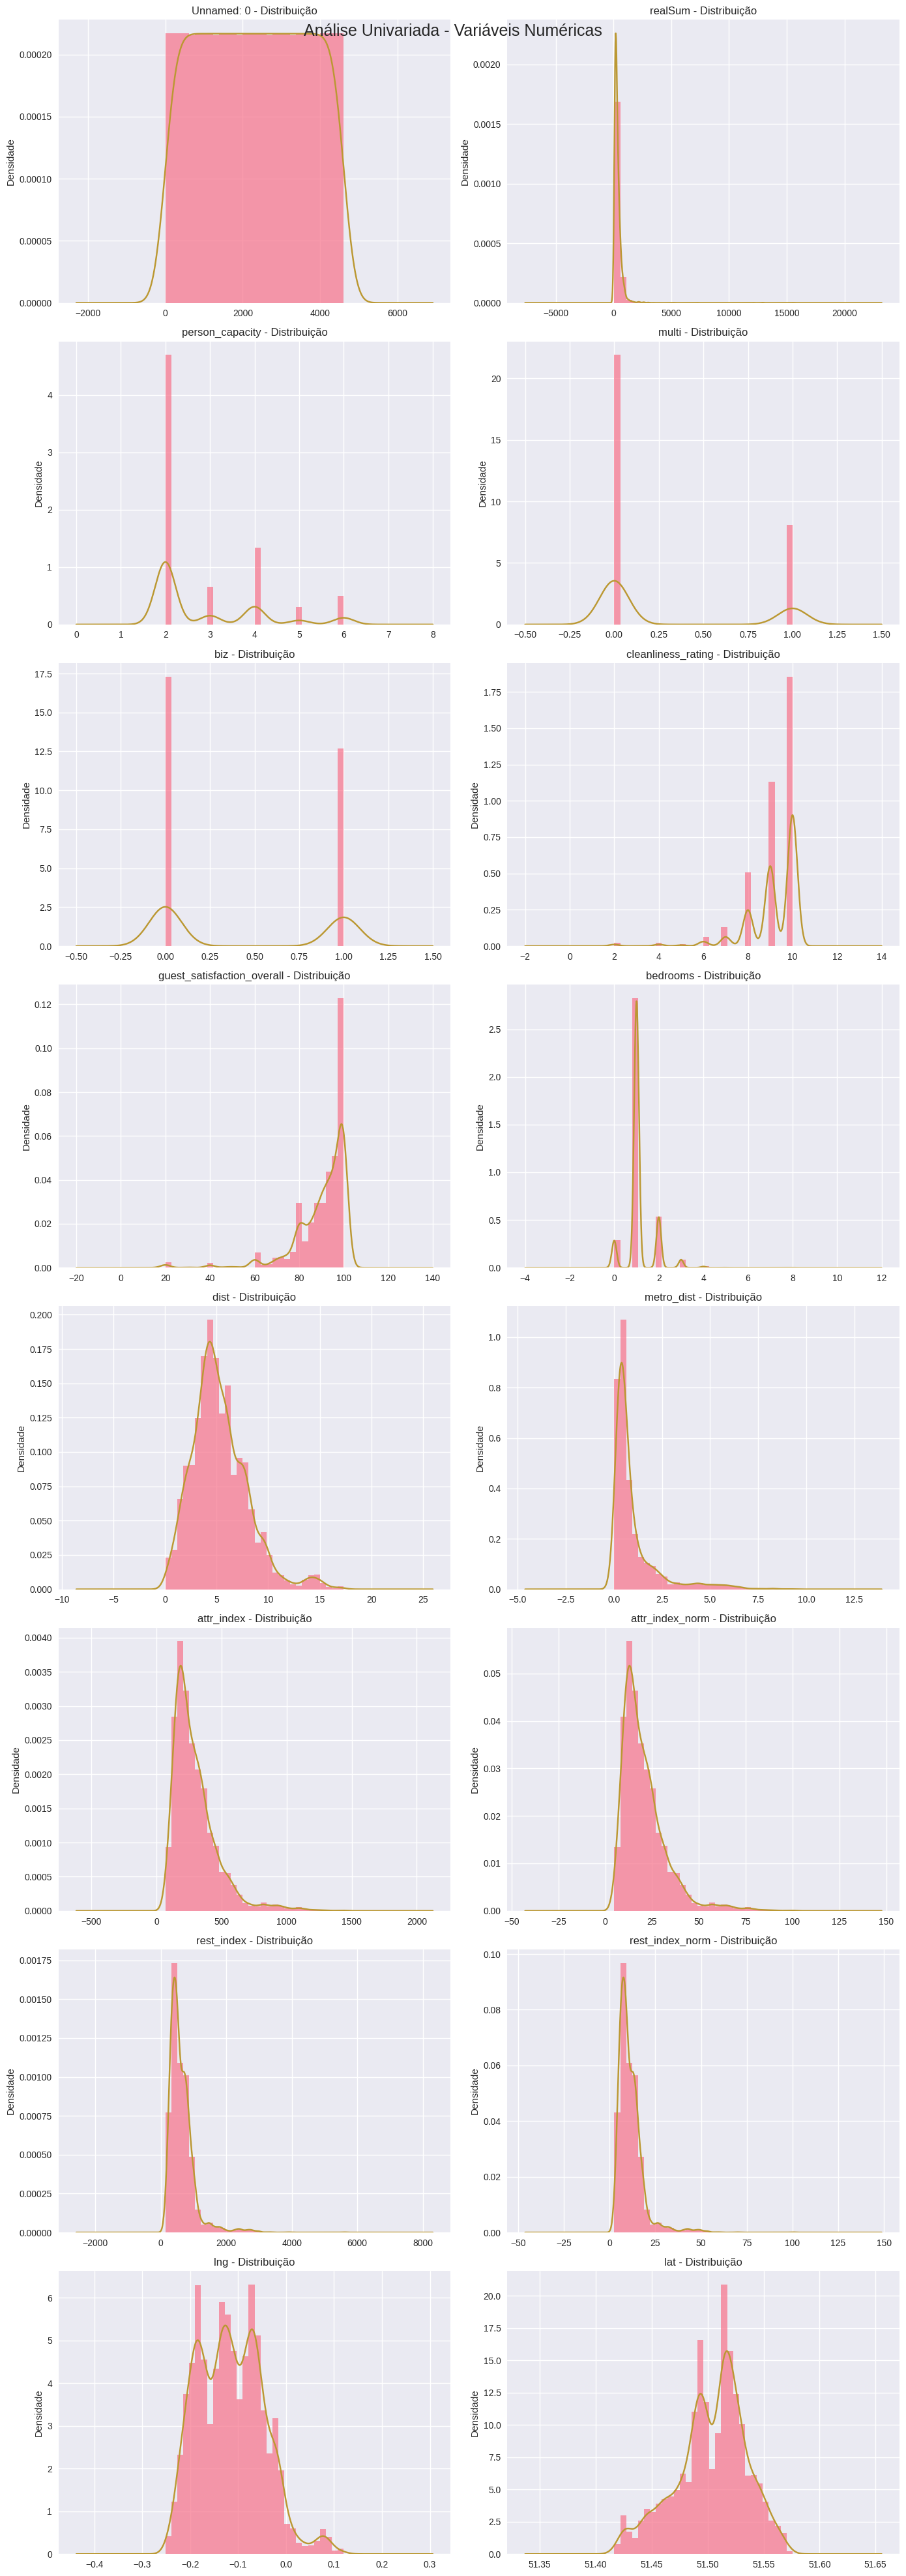

In [18]:
import math

# Total das variáveis numéricas
vars_to_plot = numeric_vars[:16]   # ou liste manualmente se preferir

cols = 2
rows = math.ceil(len(vars_to_plot) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
fig.suptitle('Análise Univariada - Variáveis Numéricas', fontsize=18)

axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]

    if var in df.columns:
        # Histograma
        ax.hist(df[var].dropna(), bins=30, alpha=0.7, density=True)

        # Linha de densidade (KDE)
        df[var].dropna().plot.density(ax=ax)

        ax.set_title(f'{var} - Distribuição')
        ax.set_ylabel('Densidade')

# Subplots vazios (caso existam)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


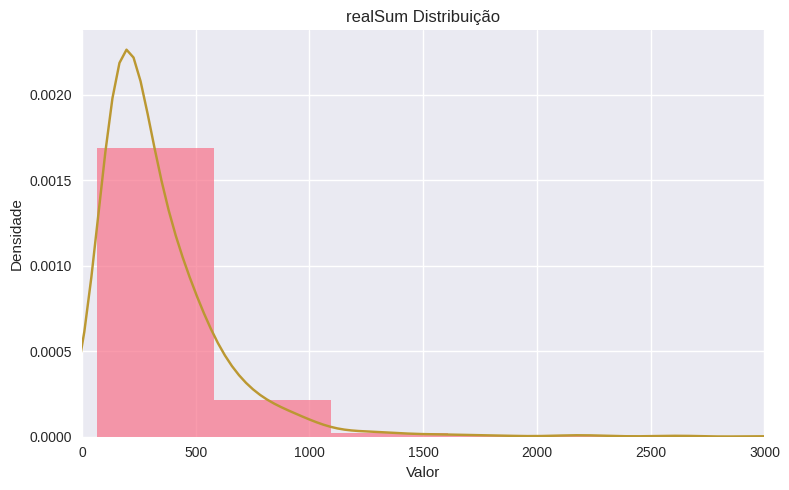

In [33]:
plt.figure(figsize=(8, 5))

plt.hist(df["realSum"].dropna(), bins=30, alpha=0.7, density=True)
df["realSum"].dropna().plot.density()

plt.title("realSum Distribuição")
plt.xlabel("Valor")
plt.ylabel("Densidade")

plt.xlim(0, 3000)   # escolha o valor ideal após observar o dataset

plt.tight_layout()
plt.show()


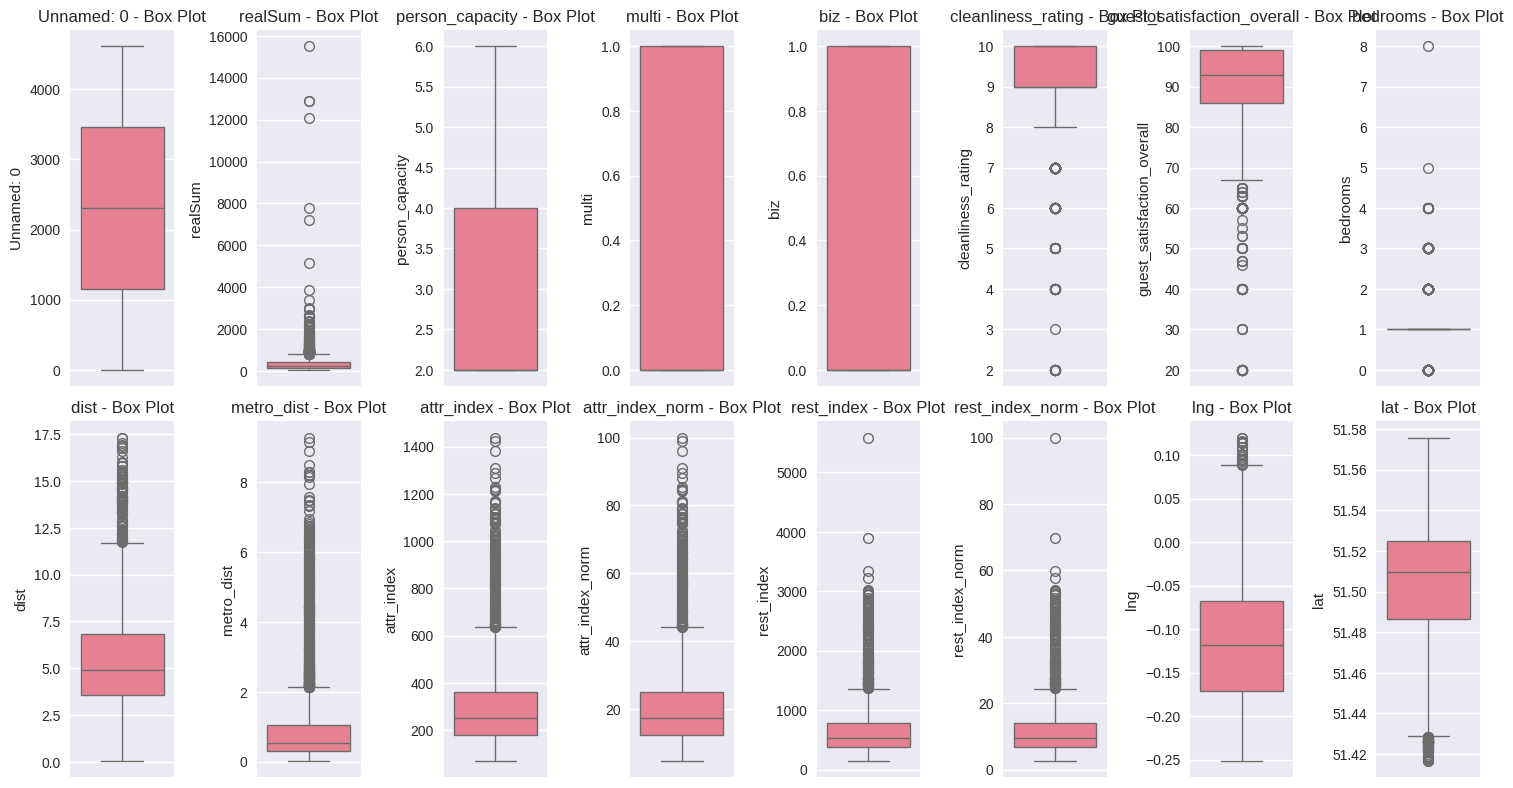

In [20]:
# Box plots para identificar outliers
plt.figure(figsize=(15, 8))
numeric_data = df[numeric_vars].select_dtypes(include=[np.number])
# Select only the first 6 numeric variables to plot
variables_to_plot = numeric_data.columns[:16]
for i, var in enumerate(variables_to_plot):
    plt.subplot(2, 8, i+1)
    sns.boxplot(y=df[var])
    plt.title(f'{var} - Box Plot')
plt.tight_layout()
plt.show()

In [21]:
# 2. ANÁLISE DE VARIÁVEIS CATEGÓRICAS
print("\n2️⃣ ANÁLISE DE VARIÁVEIS CATEGÓRICAS:")


2️⃣ ANÁLISE DE VARIÁVEIS CATEGÓRICAS:


In [22]:
# Análise de frequências
for var in categorical_vars:
    if var in df.columns:
        print(f"\n📊 {var.upper()}:")
        freq_table = df[var].value_counts()
        freq_percent = df[var].value_counts(normalize=True) * 100

        freq_df = pd.DataFrame({
            'Frequência': freq_table,
            'Percentual': freq_percent
        })
        print(freq_df.head(10))

        # Medida de concentração (Índice de Herfindahl)
        herfindahl = (freq_percent/100).pow(2).sum()
        print(f"  Índice de Herfindahl: {herfindahl:.3f}")
        print(f"  Entropia: {stats.entropy(freq_table):.3f}")


📊 ROOM_TYPE:
                 Frequência  Percentual
room_type                              
Private room           2625   56.892068
Entire home/apt        1966   42.609450
Shared room              23    0.498483
  Índice de Herfindahl: 0.505
  Entropia: 0.711


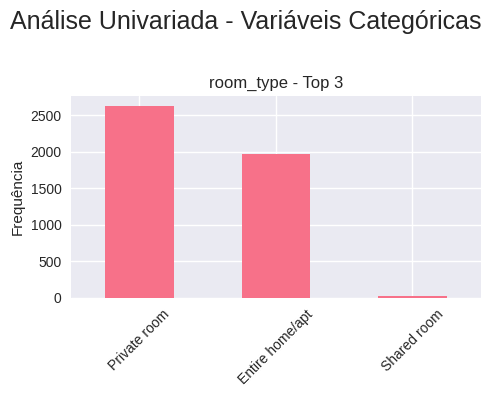

In [23]:
import math
import matplotlib.pyplot as plt

# lista de variáveis categóricas que você quer plotar
# (mantive sua variável original `categorical_vars`)
available_vars = [v for v in categorical_vars if v in df.columns]

n = len(available_vars)
if n == 0:
    print("Nenhuma variável categórica encontrada em df para plotar.")
else:
    # escolha do número de colunas (ajuste se quiser outro layout)
    max_cols = 3
    cols = min(max_cols, n)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()  # facilita indexação mesmo quando rows*cols == 1

    fig.suptitle('Análise Univariada - Variáveis Categóricas', fontsize=18)

    for idx, var in enumerate(available_vars):
        ax = axes[idx]

        # contagens completas e top (até 10)
        counts = df[var].value_counts()
        top_counts = counts.head(10)

        # escolha do tipo de gráfico:
        # Se a variável tiver <= 10 categorias, usa vertical; caso contrário usa horizontal (top 10)
        if counts.size <= 10:
            top_counts.plot(kind='bar', ax=ax)
            ax.tick_params(axis='x', rotation=45)
            ax.set_xlabel('')
            ax.set_ylabel('Frequência')
        else:
            top_counts.plot(kind='barh', ax=ax)
            ax.invert_yaxis()  # mostrar maior no topo
            ax.set_xlabel('Frequência')
            ax.set_ylabel('')

        ax.set_title(f'{var} - Top {min(10, counts.size)}')

    # esconder eixos sobrando (se houver)
    for j in range(n, rows * cols):
        axes[j].set_visible(False)

    # ajusta o layout deixando espaço para o suptitle
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


ANÁLISE EXPLORATÓRIA BIVARIADA

In [24]:
# 1. CORRELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS
print("\n1️⃣ MATRIZ DE CORRELAÇÃO:")


1️⃣ MATRIZ DE CORRELAÇÃO:


In [25]:
# Calcular matriz de correlação
correlation_matrix = df[numeric_vars].corr()

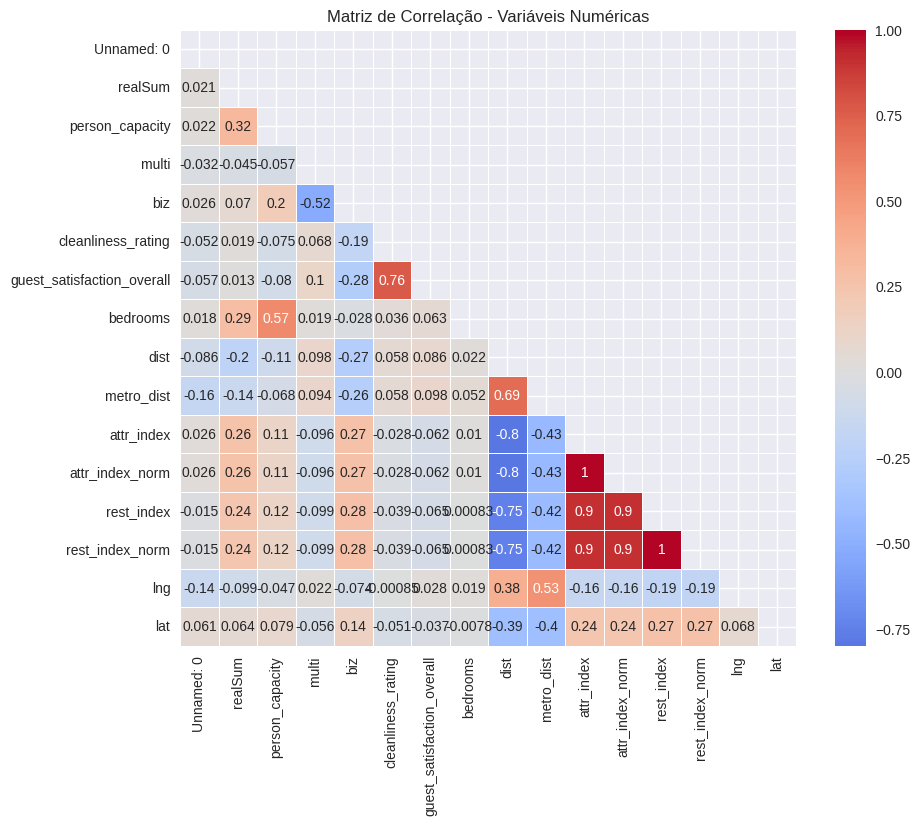

In [26]:
# Visualizar heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.show()

In [27]:
# Identificar correlações fortes
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:  # Correlação forte
            strong_corr.append({
                'var1': correlation_matrix.columns[i],
                'var2': correlation_matrix.columns[j],
                'correlation': corr_val
            })

In [28]:
if strong_corr:
    print("\n🔥 CORRELAÇÕES FORTES (|r| > 0.5):")
    for corr in strong_corr:
        print(f"  {corr['var1']} ↔ {corr['var2']}: {corr['correlation']:.3f}")


🔥 CORRELAÇÕES FORTES (|r| > 0.5):
  person_capacity ↔ bedrooms: 0.573
  multi ↔ biz: -0.520
  cleanliness_rating ↔ guest_satisfaction_overall: 0.762
  dist ↔ metro_dist: 0.691
  dist ↔ attr_index: -0.800
  dist ↔ attr_index_norm: -0.800
  dist ↔ rest_index: -0.750
  dist ↔ rest_index_norm: -0.750
  metro_dist ↔ lng: 0.532
  attr_index ↔ attr_index_norm: 1.000
  attr_index ↔ rest_index: 0.902
  attr_index ↔ rest_index_norm: 0.902
  attr_index_norm ↔ rest_index: 0.902
  attr_index_norm ↔ rest_index_norm: 0.902
  rest_index ↔ rest_index_norm: 1.000


In [29]:
# 2. ANÁLISE TARGET vs VARIÁVEIS NUMÉRICAS
print("\n2️⃣ TARGET vs VARIÁVEIS NUMÉRICAS:")


2️⃣ TARGET vs VARIÁVEIS NUMÉRICAS:


In [30]:
target_var = 'realSum'

In [31]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()

corr = df[num_cols].corr()['realSum'].abs().sort_values(ascending=False)

top3 = corr.index[1:4].tolist()  # Ignora o próprio realSum
print("Top 3 variáveis mais correlacionadas:", top3)


Top 3 variáveis mais correlacionadas: ['person_capacity', 'bedrooms', 'attr_index_norm']


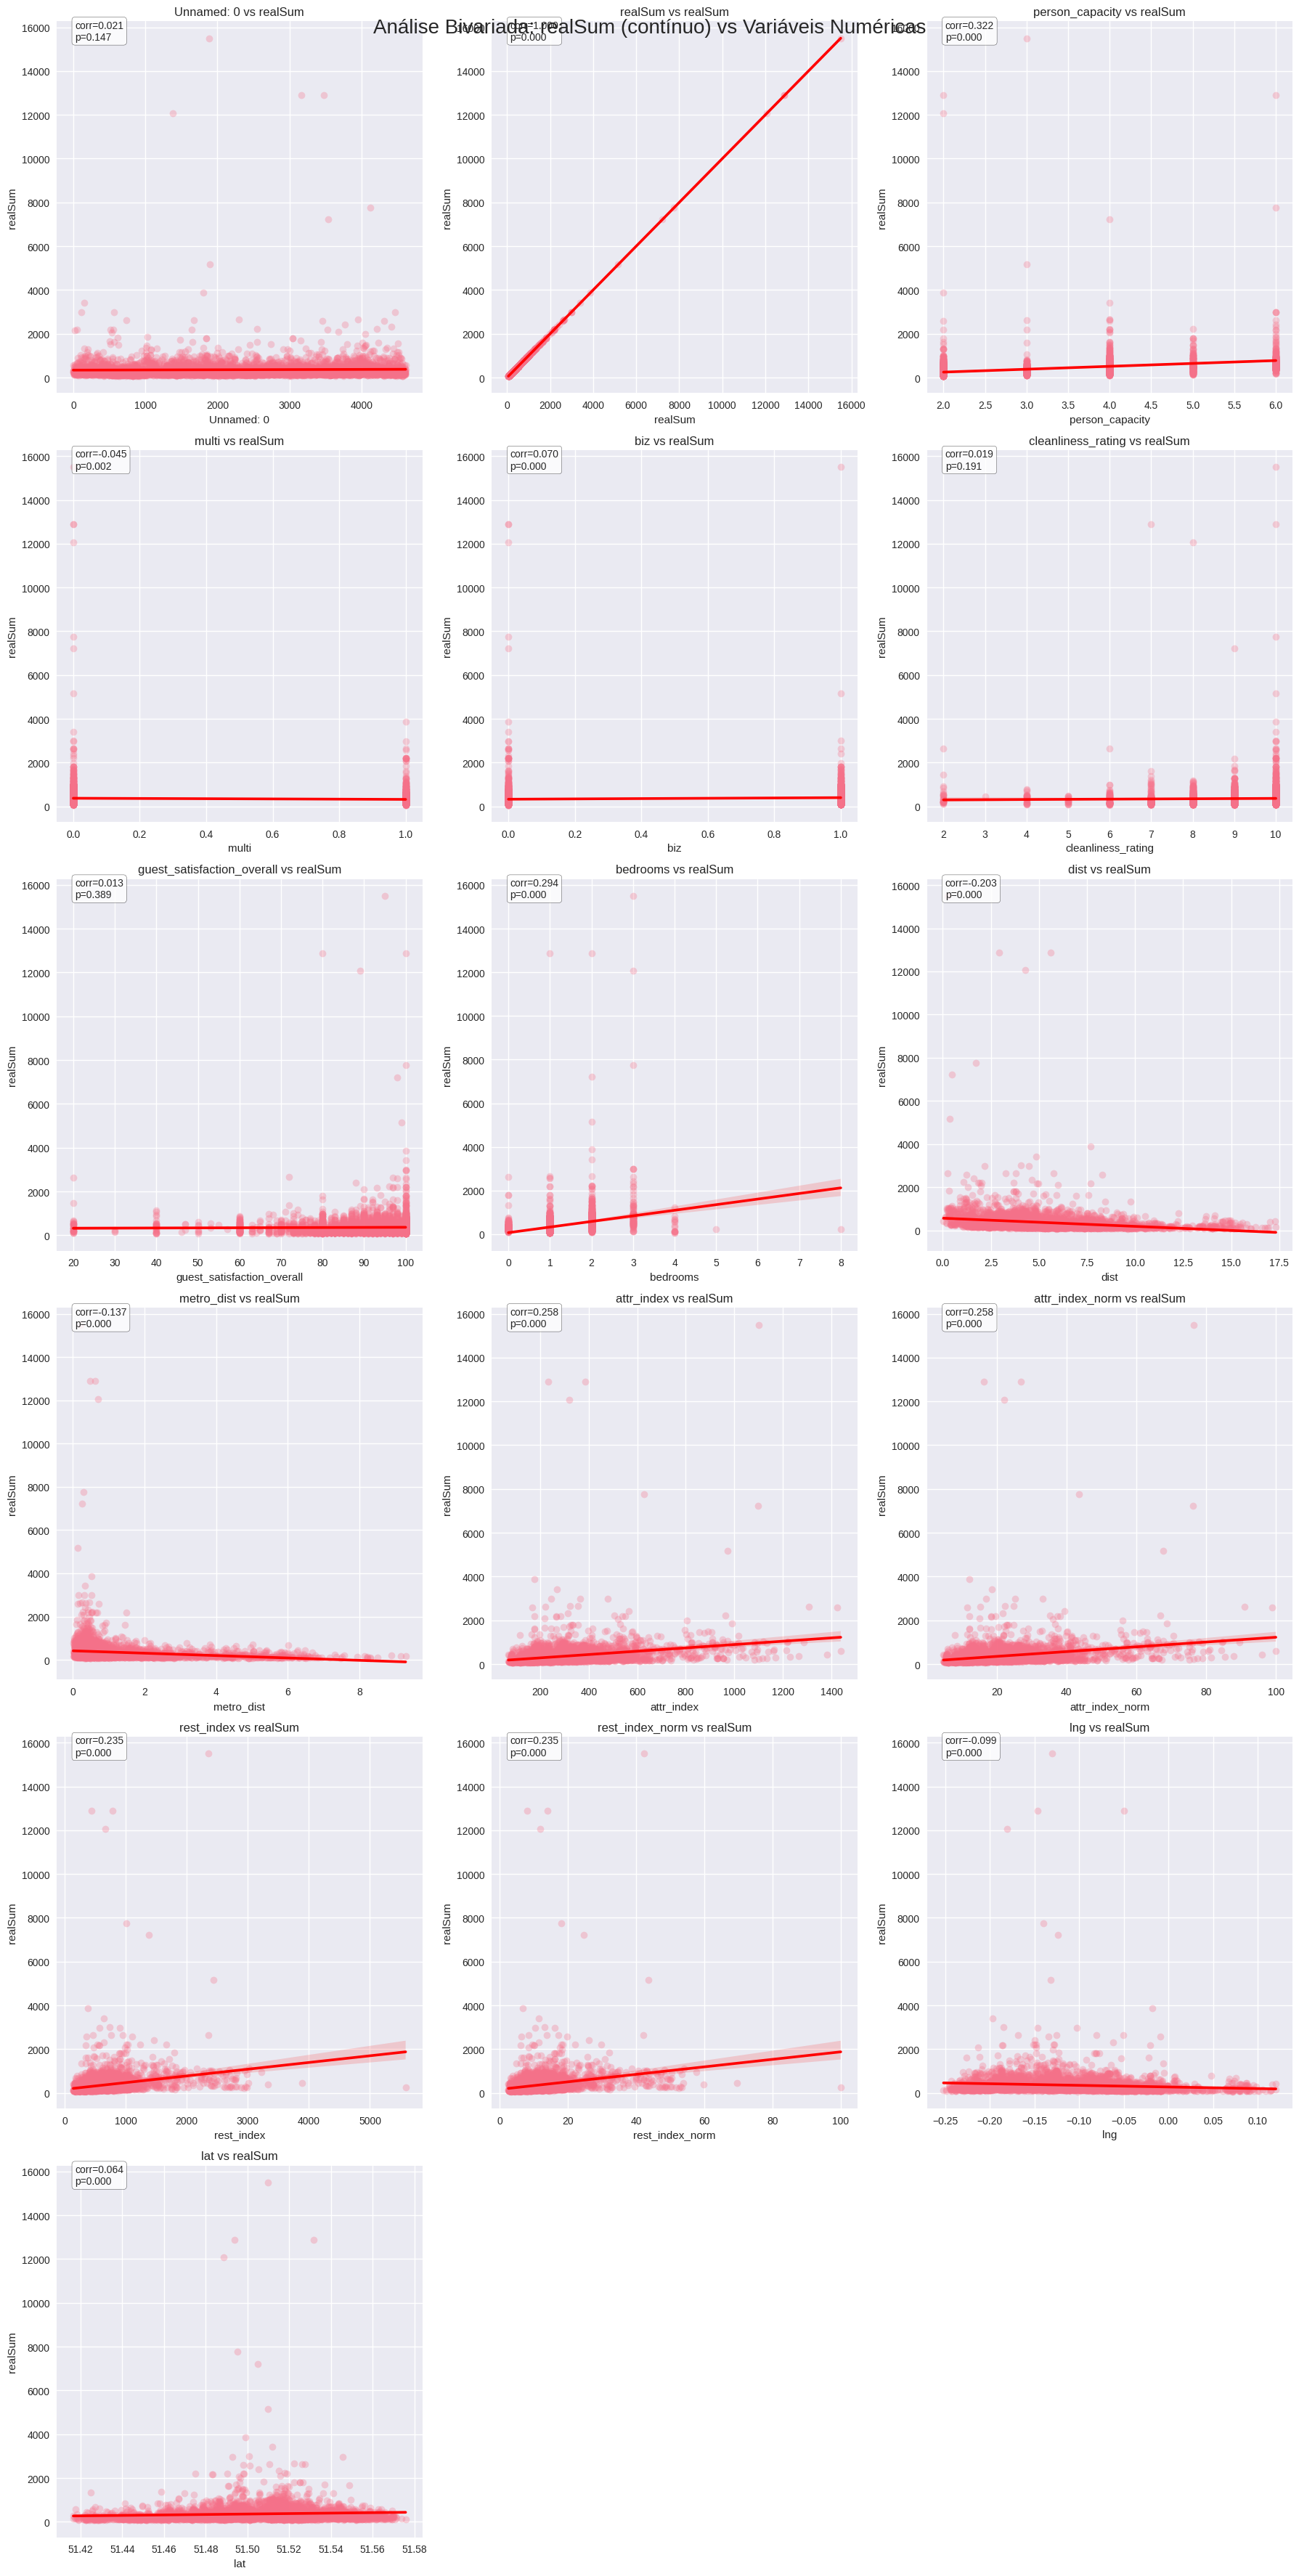

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import math

# Variáveis numéricas selecionadas para análise
numeric_for_analysis = numeric_vars
n = len(numeric_for_analysis)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
axes = axes.flatten()

fig.suptitle(f'Análise Bivariada: {target_var} (contínuo) vs Variáveis Numéricas', fontsize=20)

for i, var in enumerate(numeric_for_analysis):

    if var not in df.columns:
        continue

    ax = axes[i]

    # Scatter plot + regressão linear
    sns.regplot(
        data=df,
        x=var,
        y=target_var,
        scatter_kws={'alpha': 0.3},
        line_kws={'color': 'red'},
        ax=ax
    )
    
    ax.set_title(f'{var} vs {target_var}')

    # Correlação Pearson
    x = df[var].dropna()
    y = df[target_var].dropna()

    corr, pval = pearsonr(x, y)

    # Texto do p-value e correlação
    ax.text(
        0.05, 0.95,
        f'corr={corr:.3f}\np={pval:.3f}',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

# Remover eixos vazios (caso sobrem)
for j in range(i + 1, rows * cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [35]:
# 3. ANÁLISE TARGET vs VARIÁVEIS CATEGÓRICAS
print("\n3️⃣ TARGET vs VARIÁVEIS CATEGÓRICAS:")


3️⃣ TARGET vs VARIÁVEIS CATEGÓRICAS:


In [36]:
df["realSum_log"] = np.log1p(df["realSum"])


In [40]:
categorical_for_analysis = [
    "room_type",
    "room_shared",
    "room_private",
    "host_is_superhost",
]

for var in categorical_for_analysis:
    print(f"\n===== {var.upper()} =====")
    summary = df.groupby(var)["realSum"].agg(["count", "mean", "median", "std"]).round(2)
    print(summary)



===== ROOM_TYPE =====
                 count    mean  median     std
room_type                                     
Entire home/apt   1966  551.54  452.27  589.83
Private room      2625  218.52  176.16  380.65
Shared room         23  181.43  154.05   97.50

===== ROOM_SHARED =====
             count    mean  median     std
room_shared                               
False         4591  361.13  257.53  508.85
True            23  181.43  154.05   97.50

===== ROOM_PRIVATE =====
              count    mean  median     std
room_private                               
False          1989  547.26  451.09  587.83
True           2625  218.52  176.16  380.65

===== HOST_IS_SUPERHOST =====
                   count    mean  median     std
host_is_superhost                               
False               3936  360.35  259.18  462.14
True                 678  359.52  232.84  718.02


Variáveis válidas: ['room_type', 'room_shared', 'room_private', 'host_is_superhost', 'multi', 'biz']


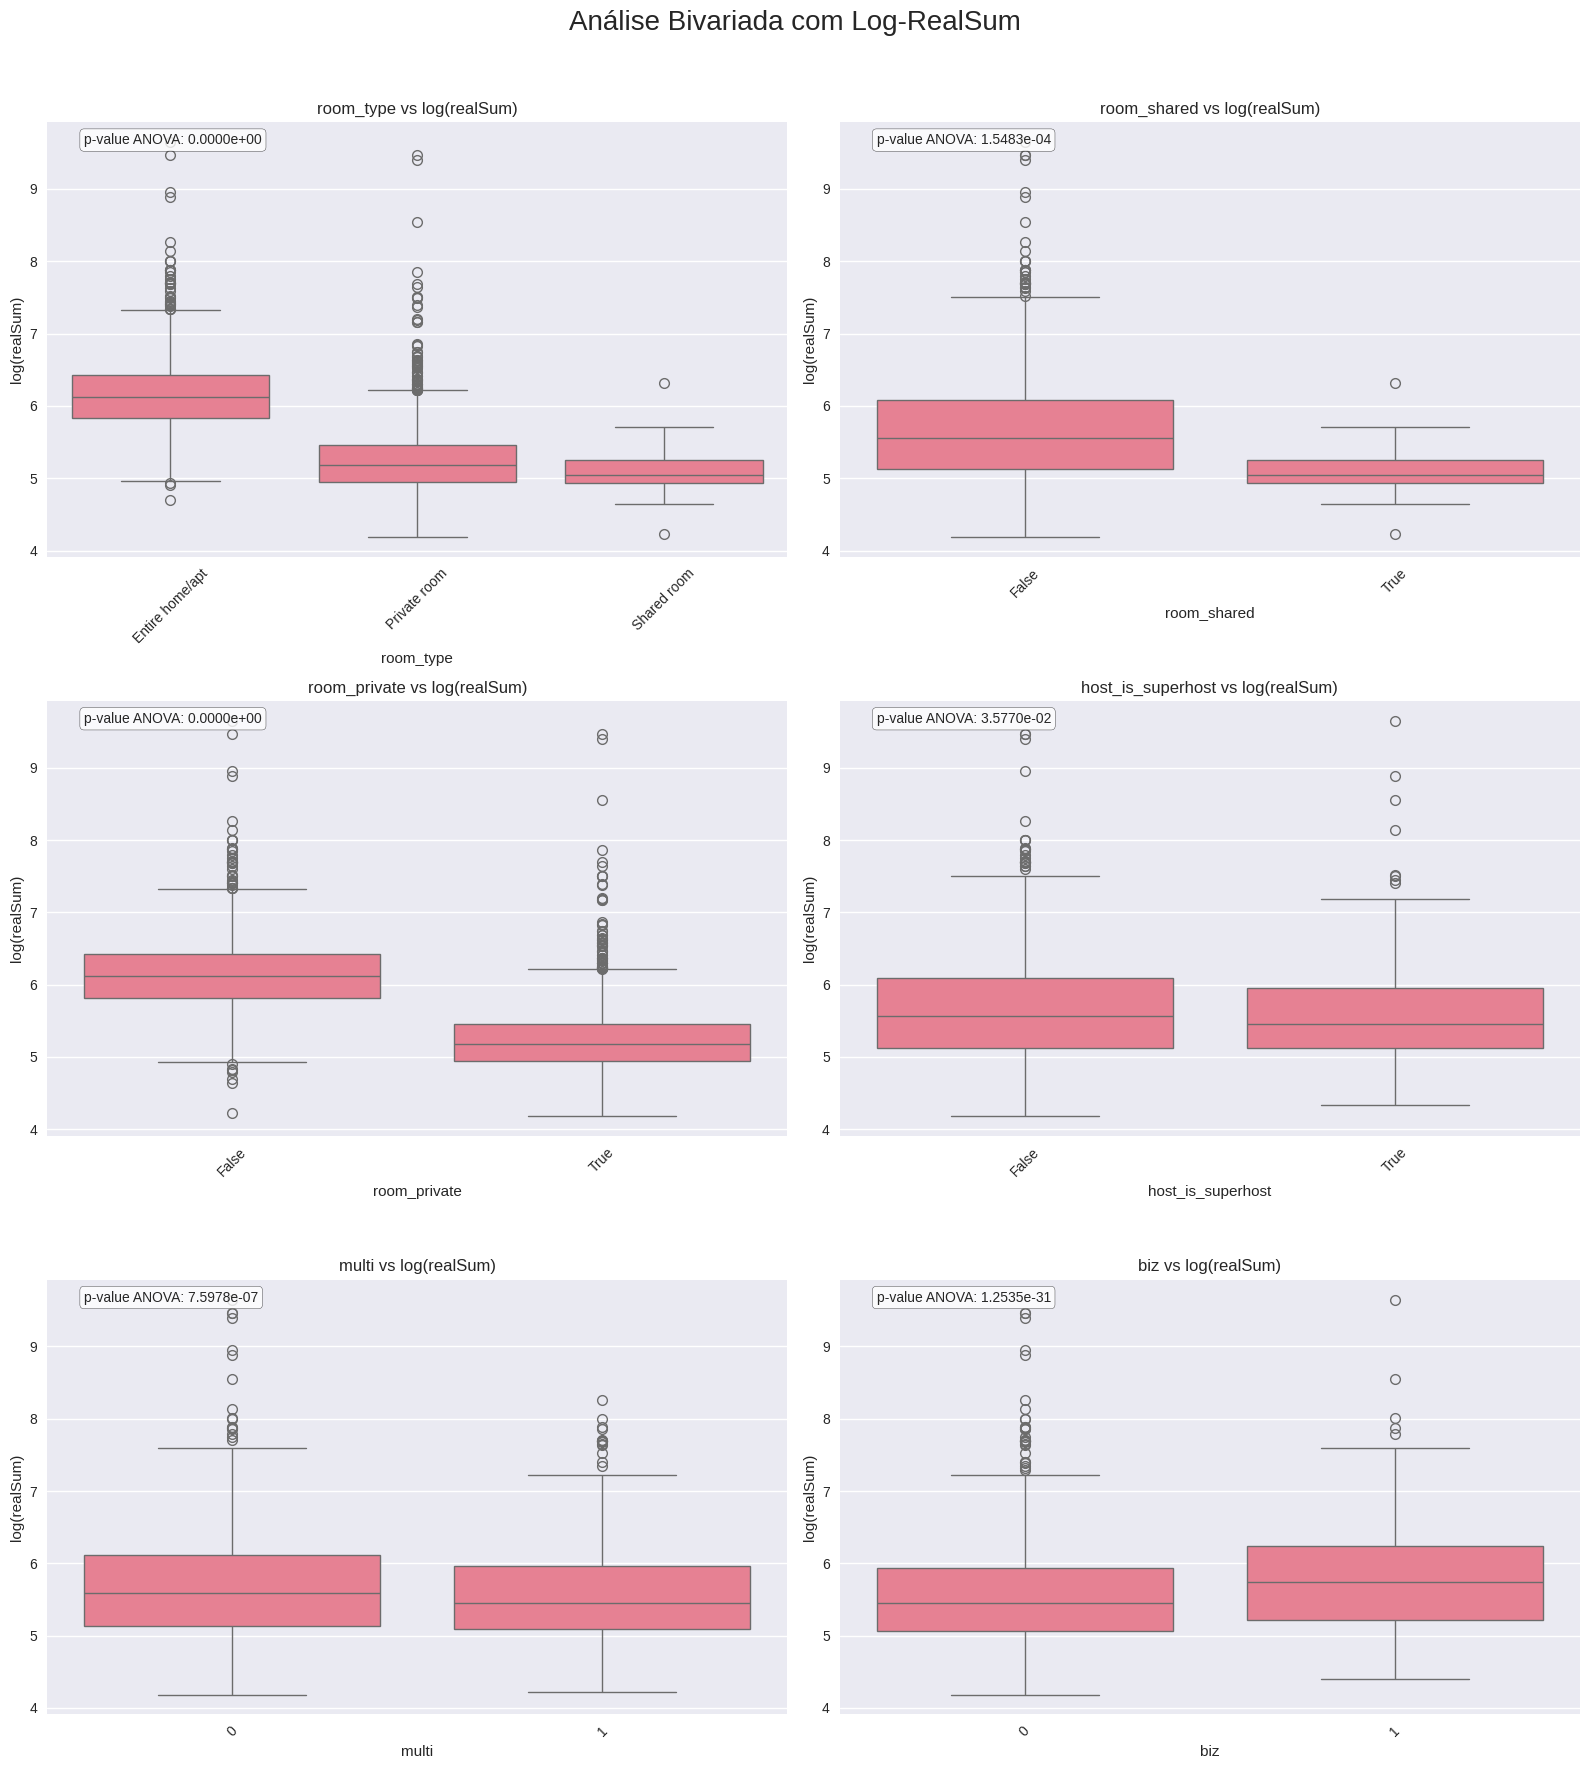

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
import numpy as np


# ✅ Garantir valores válidos para log
df = df[df["realSum"] > 0].copy()
df["realSum_log"] = np.log1p(df["realSum"])

categorical_for_analysis = [
    "room_type",
    "room_shared",
    "room_private",
    "host_is_superhost",
    "multi",
    "biz",
    "cidade",
    "tipo_dia"
]

# ✅ Filtrar apenas variáveis categóricas válidas
valid_categoricals = [
    var for var in categorical_for_analysis
    if var in df.columns and df[var].nunique() > 1
]

print("Variáveis válidas:", valid_categoricals)

# ✅ PROTEÇÃO CONTRA LISTA VAZIA
if len(valid_categoricals) == 0:
    raise ValueError("Nenhuma variável categórica válida para plotar.")

cols = 2
rows = math.ceil(len(valid_categoricals) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
axes = axes.flatten()

fig.suptitle("Análise Bivariada com Log-RealSum", fontsize=20)

for i, var in enumerate(valid_categoricals):
    ax = axes[i]

    sns.boxplot(data=df, x=var, y="realSum_log", ax=ax)

    ax.set_title(f'{var} vs log(realSum)')
    ax.set_ylabel("log(realSum)")
    ax.tick_params(axis='x', rotation=45)

    # ✅ ANOVA segura
    groups = [df[df[var] == c]["realSum_log"].dropna() for c in df[var].dropna().unique()]

    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)
        ax.text(
            0.05, 0.95,
            f'p-value ANOVA: {p_value:.4e}',
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

# ✅ Remover eixos vazios
for j in range(len(valid_categoricals), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
